# Air Quality Time-Series & Seasonal Decomposition

This notebook simulates daily Air Quality Index (AQI) sensor data across a 3-year timespan and implements a classical additive time-series decomposition. We isolate the long-term underlying trend, identify annual seasonal fluctuations, and inspect the remaining residual distributions.



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate daily timeseries data (3 years = 1095 days)
np.random.seed(101)
date_range = pd.date_range(start="2023-01-01", periods=1095, freq="D")

# Component 1: Linear upward trend (e.g. rising urban density)
trend = np.linspace(50, 72, len(date_range))

# Component 2: Seasonal cycle (annual seasonality: higher AQI in winter due to inversions/heating)
# Using cosine function with period 365 days
seasonal_year = 25 * np.cos(2 * np.pi * (date_range.dayofyear - 15) / 365.25)

# Component 3: Weekly cycle (lower emissions on weekends)
weekly_effect = np.where(date_range.dayofweek >= 5, -8.0, 3.0)

# Component 4: Random noise
noise = np.random.normal(0, 10, len(date_range))

# Combine into raw AQI data
aqi = trend + seasonal_year + weekly_effect + noise

# Build DataFrame
df = pd.DataFrame({
    "AQI": aqi,
    "Trend_True": trend,
    "Seasonal_True": seasonal_year
}, index=date_range)

df['Month'] = df.index.strftime('%b')
df['Month_Num'] = df.index.month
df['DayOfWeek'] = df.index.strftime('%a')

df.head(10)



,AQI,Trend_True,Seasonal_True,Month,Month_Num,DayOfWeek
2023-01-01,93.346984,50.000000,24.278485,Jan,1,Sun
2023-01-02,83.678900,50.020110,24.377463,Jan,1,Mon
2023-01-03,86.589141,50.040219,24.469227,Jan,1,Tue
2023-01-04,82.652336,50.060329,24.553750,Jan,1,Wed
2023-01-05,84.222625,50.080439,24.631007,Jan,1,Thu
2023-01-06,74.608344,50.100548,24.700976,Jan,1,Fri
2023-01-07,58.403523,50.120658,24.763635,Jan,1,Sat
2023-01-08,73.019387,50.140768,24.818966,Jan,1,Sun
2023-01-09,57.846148,50.160878,24.866953,Jan,1,Mon
2023-01-10,85.489789,50.180987,24.907581,Jan,1,Tue


## Classical Additive Decomposition

We implement a moving average approach to extract the time-series components:
1. **Trend Estimation**: We estimate the trend using a rolling 365-day centered average.
2. **Seasonal Estimation**: We subtract the trend, group by month of the year, and calculate the average seasonal deviation.
3. **Residual Estimation**: The remaining noise component after subtracting trend and seasonal effects.



In [2]:
# 1. Centered rolling mean for trend
df['Trend_Est'] = df['AQI'].rolling(window=365, center=True).mean()

# Fill edge values using forward/backward fill to avoid missing values in plot
df['Trend_Est'] = df['Trend_Est'].ffill().bfill()

# 2. Detrended series
df['Detrended'] = df['AQI'] - df['Trend_Est']

# 3. Monthly seasonal average index
monthly_seasonal = df.groupby('Month_Num')['Detrended'].mean()
df['Seasonal_Est'] = df['Month_Num'].map(monthly_seasonal)

# 4. Residuals
df['Residual_Est'] = df['Detrended'] - df['Seasonal_Est']

print("Decomposition metrics:")
print(f"Estimated Trend (Start): {df['Trend_Est'].iloc[0]:.2f}")
print(f"Estimated Trend (End): {df['Trend_Est'].iloc[-1]:.2f}")
print(f"Residual Std Dev: {df['Residual_Est'].std():.2f}")



Decomposition metrics:
Estimated Trend (Start): 53.92
Estimated Trend (End): 68.17
Residual Std Dev: 11.87


## Seasonal Decomposition Subplot Grid

We visualize the individual components of our air quality time-series decomposition in a four-panel Matplotlib dashboard layout.



findfont: Failed to find font weight semibold, now using 700.
<cell>:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


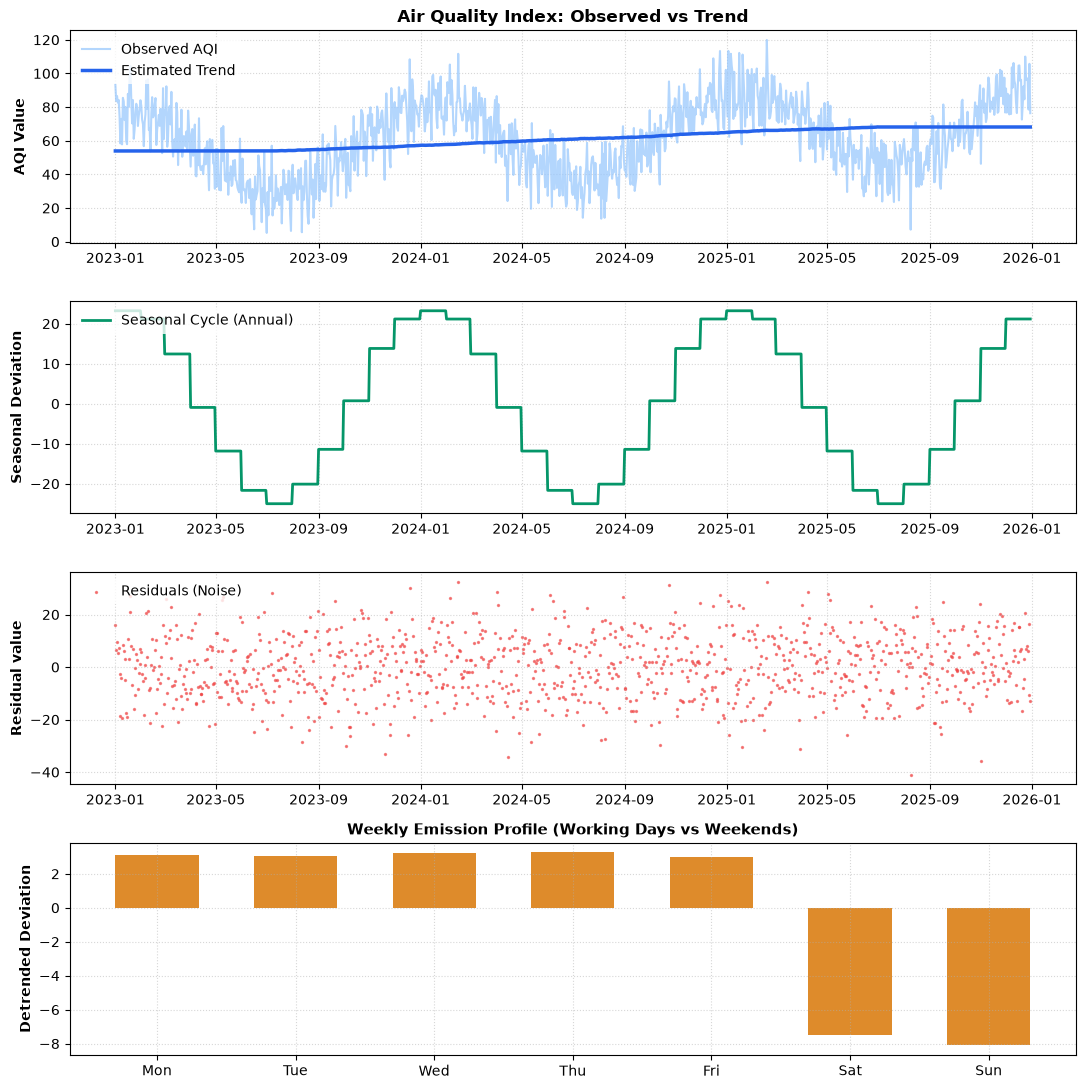

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(11, 11))

# 1. Raw vs Trend
axes[0].plot(df.index, df['AQI'], label='Observed AQI', color='#93C5FD', alpha=0.7)
axes[0].plot(df.index, df['Trend_Est'], label='Estimated Trend', color='#2563EB', linewidth=2.5)
axes[0].set_ylabel('AQI Value', fontweight='semibold')
axes[0].set_title('Air Quality Index: Observed vs Trend', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
axes[0].grid(True, linestyle=':', alpha=0.5)

# 2. Seasonal Component
axes[1].plot(df.index, df['Seasonal_Est'], label='Seasonal Cycle (Annual)', color='#059669', linewidth=2)
axes[1].set_ylabel('Seasonal Deviation', fontweight='semibold')
axes[1].legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
axes[1].grid(True, linestyle=':', alpha=0.5)

# 3. Residual noise
axes[2].scatter(df.index, df['Residual_Est'], label='Residuals (Noise)', color='#EF4444', s=2, alpha=0.6)
axes[2].set_ylabel('Residual value', fontweight='semibold')
axes[2].legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
axes[2].grid(True, linestyle=':', alpha=0.5)

# 4. Weekly emissions signature
weekly_avg = df.groupby(df.index.dayofweek)['Detrended'].mean()
week_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[3].bar(week_days, weekly_avg, color='#D97706', alpha=0.85, width=0.6)
axes[3].set_ylabel('Detrended Deviation', fontweight='semibold')
axes[3].set_title('Weekly Emission Profile (Working Days vs Weekends)', fontsize=11, fontweight='bold')
axes[3].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()



## Monthly Seasonal Boxplot Distributions

Using Seaborn, we visualize the monthly distribution of raw AQI readings. The boxplots demonstrate how seasonal winter conditions lift the median AQI levels compared to summer months.



<cell>:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


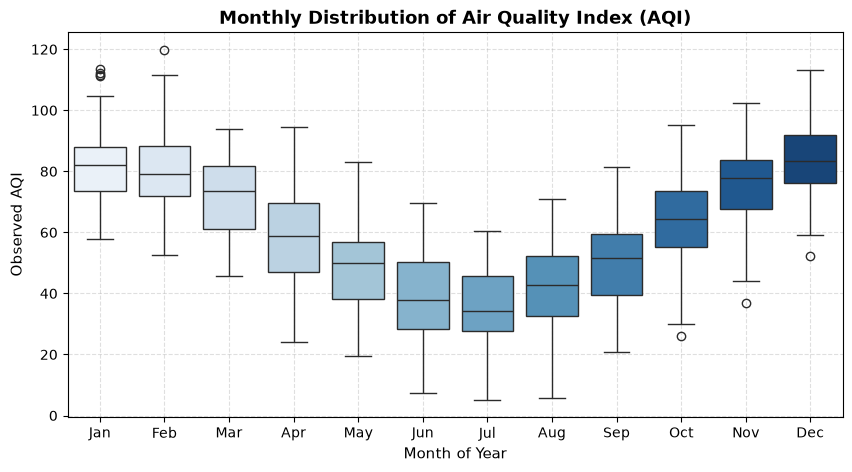

In [4]:
plt.figure(figsize=(10, 5))
ordered_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sns.boxplot(
    data=df, 
    x='Month', 
    y='AQI', 
    order=ordered_months,
    palette='Blues',
    hue='Month',
    legend=False
)

plt.title('Monthly Distribution of Air Quality Index (AQI)', fontsize=13, fontweight='bold')
plt.xlabel('Month of Year', fontsize=11)
plt.ylabel('Observed AQI', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()
